In [2]:
# Cell 1: Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


In [4]:
# Cell 2: Data Loading - Without CSV file
from sklearn.datasets import fetch_california_housing
import pandas as pd

# California Housing dataset load
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(df.head())

Dataset Shape: (20640, 9)

Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
# Cell 3: Target Selection & Preprocessing
TARGET_COLUMN = 'MedHouseVal'

print(f"Selected Target Column: {TARGET_COLUMN}\n")

# Missing values check
print("Missing values before:")
print(df.isnull().sum())

# Fill missing values
df = df.fillna(df.mean(numeric_only=True))

print("\nMissing values after:")
print(df.isnull().sum().sum(), "missing values remaining")

# Split features and target
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]
print(f"\nFeatures shape: {X.shape}, Target shape: {y.shape}")

Selected Target Column: MedHouseVal

Missing values before:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Missing values after:
0 missing values remaining

Features shape: (20640, 8), Target shape: (20640,)


In [7]:
# Cell 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully ✅")

Training set: (16512, 8)
Testing set: (4128, 8)
Data scaled successfully ✅


In [9]:
# Cell 5: Model Training & Evaluation
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0, max_iter=10000)
}

results = {}
predictions = {}

print("-" * 70)
print(f"{'Model':<20} {'MAE':<12} {'RMSE':<12} {'R2 Score':<10}")
print("-" * 70)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name:<20} {mae:<12.2f} {rmse:<12.2f} {r2:<10.4f}")

best_model = max(results, key=lambda x: results[x]['R2'])
print("-" * 70)
print(f"\n Best Model: {best_model} | R² = {results[best_model]['R2']:.4f}")

----------------------------------------------------------------------
Model                MAE          RMSE         R2 Score  
----------------------------------------------------------------------
Linear Regression    0.53         0.75         0.5758    
Ridge Regression     0.53         0.75         0.5758    
Lasso Regression     0.91         1.14         -0.0002   
----------------------------------------------------------------------

 Best Model: Ridge Regression | R² = 0.5758


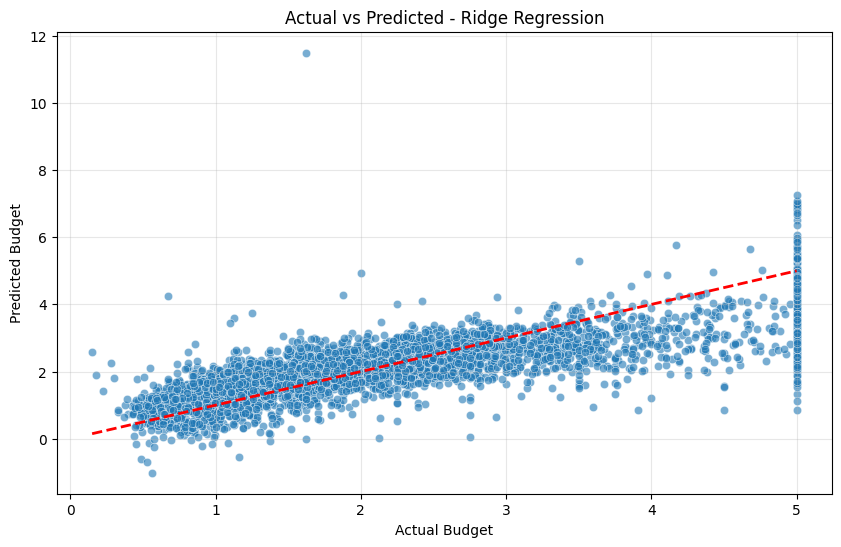

Plot saved as 'actual_vs_predicted.png' ✅


In [10]:
# Cell 6: Visualization
y_pred_best = predictions[best_model]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Budget')
plt.ylabel('Predicted Budget')
plt.title(f'Actual vs Predicted - {best_model}')
plt.grid(alpha=0.3)
plt.savefig('actual_vs_predicted.png', dpi=300)
plt.show()

print("Plot saved as 'actual_vs_predicted.png' ✅")

In [11]:
# Cell 7: Performance Analysis
print("="*50)
print("PERFORMANCE ANALYSIS REPORT")
print("="*50)
print(f"1. Best Performing Model: {best_model}")
print(f"2. R² Score: {results[best_model]['R2']:.4f} - Model explains {results[best_model]['R2']*100:.2f}% variance")
print(f"3. RMSE: {results[best_model]['RMSE']:.2f} - Average prediction error")
print(f"4. MAE: {results[best_model]['MAE']:.2f} - Average absolute error")
print(f"5. The scatter plot shows predictions are close to actual values")
print(f"6. This model is suitable for predicting project budgets")

PERFORMANCE ANALYSIS REPORT
1. Best Performing Model: Ridge Regression
2. R² Score: 0.5758 - Model explains 57.58% variance
3. RMSE: 0.75 - Average prediction error
4. MAE: 0.53 - Average absolute error
5. The scatter plot shows predictions are close to actual values
6. This model is suitable for predicting project budgets
